# Climate Data Explorer: Turkey Temperature Analysis

This notebook explores long-term changes in Turkey's annual average surface temperature from 1940 to 2025.

## 1. Import Libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load the Dataset

In [2]:
url = "https://ourworldindata.org/grapher/average-annual-surface-temperature.csv?v=1&csvType=full&useColumnShortNames=false"

df = pd.read_csv(
    url,
    storage_options={
        "User-Agent": "Our World In Data data fetch/1.0"
    }
)

## 3. Explore the Dataset

In [3]:
df.head()

,Entity,Code,Year,Average surface temperature
0,Afghanistan,AFG,1940,11.327695
1,Afghanistan,AFG,1941,13.324756
2,Afghanistan,AFG,1942,12.885448
3,Afghanistan,AFG,1943,11.524769
4,Afghanistan,AFG,1944,12.143665


In [4]:
df.shape

(18318, 4)

In [5]:
df.columns

Index(['Entity', 'Code', 'Year', 'Average surface temperature'], dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18318 entries, 0 to 18317
Data columns (total 4 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Entity                       18318 non-null  str    
 1   Code                         16770 non-null  str    
 2   Year                         18318 non-null  int64  
 3   Average surface temperature  18318 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 572.6 KB


## 4. Filter Turkey Data

In [7]:
turkey_df = df[df["Entity"] == "Turkey"]
turkey_df.head()

,Entity,Code,Year,Average surface temperature
16856,Turkey,TUR,1940,9.931272
16857,Turkey,TUR,1941,9.885047
16858,Turkey,TUR,1942,9.954412
16859,Turkey,TUR,1943,10.157193
16860,Turkey,TUR,1944,10.124280


## 5. Descriptive Statistics

In [8]:
print("First year:",turkey_df["Year"].min())
print("Last year:", turkey_df["Year"].max())
print("Number of observations:" , len(turkey_df))

First year: 1940
Last year: 2025
Number of observations: 86


In [10]:
print("Average:", round(turkey_df["Average surface temperature"].mean(),2))
print("Minimum:",round(turkey_df["Average surface temperature"].min(),2))
print("Maximum:",round(turkey_df["Average surface temperature"].max(),2))


Average: 11.1
Minimum: 9.13
Maximum: 13.34


In [14]:
coldest_index = turkey_df["Average surface temperature"].idxmin()
turkey_df.loc[coldest_index]

Entity                           Turkey
Code                                TUR
Year                               1949
Average surface temperature    9.132471
Name: 16865, dtype: object

In [13]:
hottest_index = turkey_df["Average surface temperature"].idxmax()
turkey_df.loc[hottest_index]

Entity                            Turkey
Code                                 TUR
Year                                2024
Average surface temperature    13.342423
Name: 16940, dtype: object

## 6. Moving Average Analysis

In [40]:
turkey_df = turkey_df.copy()

turkey_df["10-Year Moving Average"] = (
turkey_df["Average surface temperature"]
.rolling(window=10)
.mean()   
)

## 7. Linear Trend Analysis

In [41]:
slope, intercept = np.polyfit(
    turkey_df["Year"],
    turkey_df["Average surface temperature"],
    1
)

print("Slope:", slope)
print("Intercept:", intercept)

Slope: 0.027643217840464123
Intercept: -43.70047546174338


In [42]:
slope_per_decade = slope * 10
print("Temperature trend per decade:" , round(slope_per_decade, 3), "°C")

Temperature trend per decade: 0.276 °C


In [43]:
turkey_df["Linear Trend"] = (
    slope * turkey_df["Year"] + intercept
)

## 8. Visualization

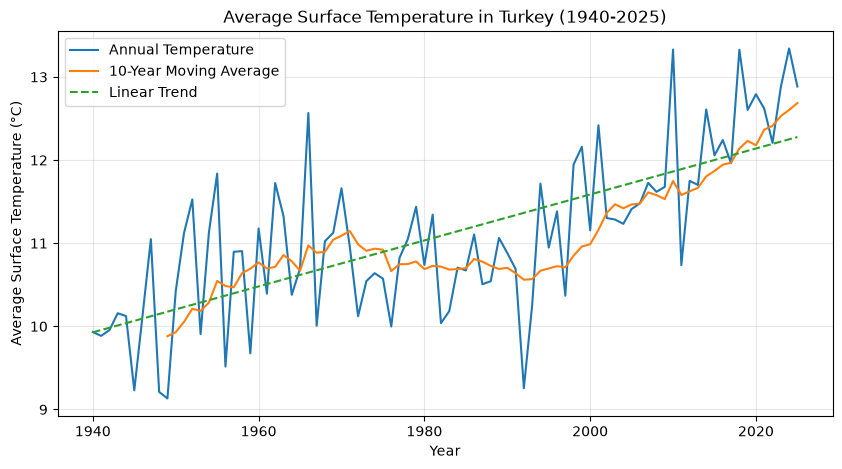

In [44]:
plt.figure(figsize=(10,5))
plt.plot(
    turkey_df["Year"],
    turkey_df["Average surface temperature"],
    label="Annual Temperature"
)
plt.plot(
    turkey_df["Year"],
    turkey_df["10-Year Moving Average"],
    label="10-Year Moving Average"
)
plt.plot(
    turkey_df["Year"],
    turkey_df["Linear Trend"],
    linestyle="--",
    label="Linear Trend"
)
plt.xlabel("Year")
plt.ylabel("Average Surface Temperature (°C)")
plt.title("Average Surface Temperature in Turkey (1940-2025)")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    "../visualizations/turkey_temperature_trend.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Key Findings

- Turkey's annual surface temperature shows substantial year-to-year variability.
- The 10-year moving average reveals a clearer long-term warming pattern.
- The linear trend for 1940–2025 is approximately **+0.28 °C per decade**.
- Higher annual temperatures become more frequent in the later part of the dataset.

> The linear trend summarizes the overall pattern across the full period and should not be interpreted as a constant temperature increase in every individual decade.